In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print("All libraries are ready!")

All libraries are ready!


In [4]:
# Real spam messages dataset
emails = [
    # Spam messages
    "Win free iPhone now click here",
    "You won 1 million dollars claim now",
    "Free money transfer click link",
    "Congratulations you won a prize",
    "Buy cheap medicines online now",
    "Click here to claim your reward",
    "You have been selected for cash prize",
    "Free lottery winner claim your money",
    "Special offer buy now get discount",
    "Urgent your account needs verification click",
    
    # Normal messages
    "Hey can we meet tomorrow for lunch",
    "Please send me the project report",
    "Happy birthday have a great day",
    "What time is the meeting today",
    "Can you help me with homework",
    "I will be late to office today",
    "Please review my assignment thanks",
    "Let us catch up this weekend",
    "Good morning how are you doing",
    "Can you call me when you are free"
]

labels = [
    1,1,1,1,1,1,1,1,1,1,  # 1 = Spam
    0,0,0,0,0,0,0,0,0,0   # 0 = Normal
]

df = pd.DataFrame({"Email": emails, "Label": labels})
df["Type"] = df["Label"].map({1: "SPAM", 0: "Normal"})

print(df)
print(f"\nTotal Emails: {len(df)}")
print(f"Spam   : {df['Label'].sum()}")
print(f"Normal : {len(df) - df['Label'].sum()}")

                                           Email  Label    Type
0                 Win free iPhone now click here      1    SPAM
1            You won 1 million dollars claim now      1    SPAM
2                 Free money transfer click link      1    SPAM
3                Congratulations you won a prize      1    SPAM
4                 Buy cheap medicines online now      1    SPAM
5                Click here to claim your reward      1    SPAM
6          You have been selected for cash prize      1    SPAM
7           Free lottery winner claim your money      1    SPAM
8             Special offer buy now get discount      1    SPAM
9   Urgent your account needs verification click      1    SPAM
10            Hey can we meet tomorrow for lunch      0  Normal
11             Please send me the project report      0  Normal
12               Happy birthday have a great day      0  Normal
13                What time is the meeting today      0  Normal
14                 Can you help me with 

In [6]:
# ML do not know text so converts in numbers
# CountVectorizer make every word a number

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["Email"])
y = df["Label"]

print("Email text → Converted in to numbers!")
print(f"Shape: {X.shape}")
print(f"Words detected: {len(vectorizer.vocabulary_)}")
print("\nSome words found:")
words = list(vectorizer.vocabulary_.keys())[:10]
print(words)

Email text → Converted in to numbers!
Shape: (20, 83)
Words detected: 83

Some words found:
['win', 'free', 'iphone', 'now', 'click', 'here', 'you', 'won', 'million', 'dollars']


In [7]:
# Data split  80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data  : {X_train.shape[0]} emails")
print(f"Testing data   : {X_test.shape[0]} emails")

# Naive Bayes Model — best for Spam detection! 
model = MultinomialNB()
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")

Training data  : 16 emails
Testing data   : 4 emails

✅ Model trained successfully!


In [8]:
# Predictions
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("=" * 40)
print("   SPAM DETECTION RESULTS")
print("=" * 40)
print(f"Accuracy: {accuracy * 100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions,
      target_names=["Normal", "Spam"]))

   SPAM DETECTION RESULTS
Accuracy: 50.0%

Detailed Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         2
        Spam       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



C:\Users\hp\anaconda3.1\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3.1\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3.1\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
def check_spam(email):
    email_vectorized = vectorizer.transform([email])
    prediction = model.predict(email_vectorized)
    probability = model.predict_proba(email_vectorized)
    
    result = "🚨 SPAM!" if prediction[0] == 1 else "✅ Normal"
    confidence = max(probability[0]) * 100
    
    print(f"Email     : {email}")
    print(f"Result    : {result}")
    print(f"Confidence: {confidence:.1f}%")
    print("-" * 40)

# Test!
check_spam("You won free iPhone click here now")
check_spam("Can we meet for coffee tomorrow")
check_spam("Claim your free money prize now")
check_spam("Please send me the homework notes")
check_spam("Win lottery million dollars free")

Email     : You won free iPhone click here now
Result    : 🚨 SPAM!
Confidence: 98.2%
----------------------------------------
Email     : Can we meet for coffee tomorrow
Result    : ✅ Normal
Confidence: 96.5%
----------------------------------------
Email     : Claim your free money prize now
Result    : 🚨 SPAM!
Confidence: 99.8%
----------------------------------------
Email     : Please send me the homework notes
Result    : ✅ Normal
Confidence: 99.2%
----------------------------------------
Email     : Win lottery million dollars free
Result    : 🚨 SPAM!
Confidence: 77.8%
----------------------------------------


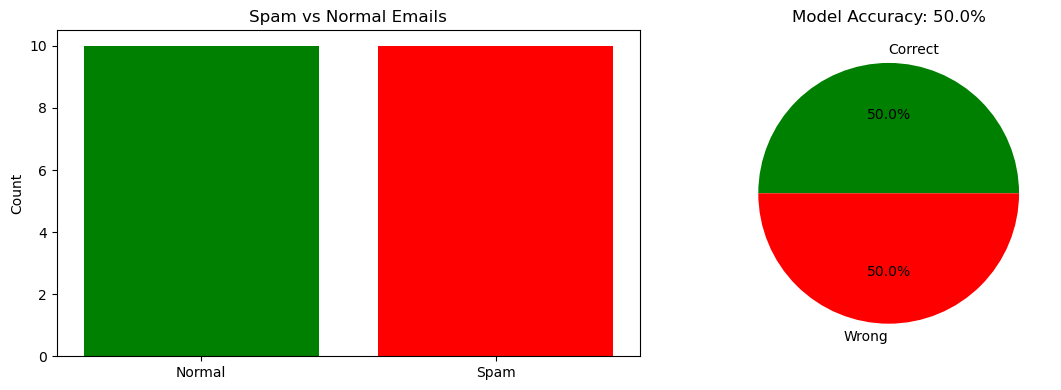

In [10]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Spam vs Normal count
ax1.bar(["Normal", "Spam"], 
        [len(df[df["Label"]==0]), len(df[df["Label"]==1])],
        color=["green", "red"])
ax1.set_title("Spam vs Normal Emails")
ax1.set_ylabel("Count")

# Accuracy pie chart
ax2.pie([accuracy*100, (1-accuracy)*100],
        labels=["Correct", "Wrong"],
        colors=["green", "red"],
        autopct="%1.1f%%")
ax2.set_title(f"Model Accuracy: {accuracy*100:.1f}%")

plt.tight_layout()
plt.show()

In [11]:
my_email = input("Apna email likho: Hey can we meet tomorrow? ")
check_spam(my_email)





Apna email likho: Hey can we meet tomorrow?  123dolphin@gmail.com


Email     : 123dolphin@gmail.com
Result    : ✅ Normal
Confidence: 50.0%
----------------------------------------
